In [ ]:
# Copia do Drive para o disco local do Colab (SSD)
!cp "/content/drive/MyDrive/FIAP - IA para devs/Fase 1/Dados visao computacional/archive.zip" "/content/"

# Descompacta silenciosamente (-q) na pasta local
!unzip -q "/content/archive.zip" -d "/content/dados_locais/"

import os, cv2, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              ConfusionMatrixDisplay, recall_score, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

CSV_DIR = "/content/dados_locais/archive (1)/csv"
IMG_DIR = "/content/dados_locais/archive (1)/jpeg"
IMG_SIZE = (300, 300)      # Aumentado para 300x300 para o EfficientNetB3 capturar mais detalhes
BATCH_SIZE = 32
SEED = 42


In [ ]:
def load_metadata():
    mass_train = pd.read_csv(f"{CSV_DIR}/mass_case_description_train_set.csv")
    calc_train = pd.read_csv(f"{CSV_DIR}/calc_case_description_train_set.csv")
    mass_test  = pd.read_csv(f"{CSV_DIR}/mass_case_description_test_set.csv")
    calc_test  = pd.read_csv(f"{CSV_DIR}/calc_case_description_test_set.csv")
    dicom      = pd.read_csv(f"{CSV_DIR}/dicom_info.csv")

    df = pd.concat([mass_train, calc_train, mass_test, calc_test], ignore_index=True)

    df["label"] = df["pathology"].apply(lambda x: 1 if str(x).strip().upper() == "MALIGNANT" else 0)
    df["case_id"] = df["cropped image file path"].apply(lambda p: p.split("/")[0])

    def extract_patient_id(case_id):
        parts = case_id.split("_")
        idx = parts.index("P") if "P" in parts else 1
        return "_".join(parts[idx:idx+2])

    df["patient_id"] = df["case_id"].apply(extract_patient_id)
    df["view"] = df["image view"].str.upper()

    df["assessment"] = pd.to_numeric(df["assessment"], errors="coerce")
    df["stage"] = df["assessment"].apply(lambda a: "Early" if a <= 3 else "Late")

    dicom_cropped = dicom[dicom["SeriesDescription"] == "cropped images"].copy()
    dicom_cropped = dicom_cropped.rename(columns={"PatientID": "case_id"}).drop_duplicates("case_id")
    df = df.merge(dicom_cropped[["case_id", "image_path"]], on="case_id", how="inner")

    # --- OTIMIZAÇÃO DE LEITURA (Drive) ---
    # O método antigo `os.path.exists` validava arquivo por arquivo, o que causa latência alta no Drive.
    # Agora listamos todos os JPEGs de uma vez (apenas 1 request ao SO) para um mapa na memória O(1).
    import glob
    print("Escaneando diretório de imagens para otimização (isso é feito apenas uma vez)...")
    all_imgs = glob.glob(os.path.join(IMG_DIR, "**", "*.jpg"), recursive=True)
    valid_paths = set(all_imgs)

    df["img_path"] = df["image_path"].apply(lambda p: os.path.join(IMG_DIR, p.split("jpeg/")[-1]))

    # Filtra mantendo apenas as imagens cujos caminhos existem no nosso Set
    df = df[df["img_path"].isin(valid_paths)].reset_index(drop=True)

    return df[["img_path", "label", "patient_id", "view", "assessment", "stage"]]

df = load_metadata()
print("Total images:", len(df))
print("Unique patients:", df["patient_id"].nunique())
display(df.head())

Escaneando diretório de imagens para otimização (isso é feito apenas uma vez)...
Total images: 3567
Unique patients: 1566


,img_path,label,patient_id,view,assessment,stage
0,/content/dados_locais/archive (1)/jpeg/1.3.6.1...,1,P_00001,CC,4,Late
1,/content/dados_locais/archive (1)/jpeg/1.3.6.1...,1,P_00001,MLO,4,Late
2,/content/dados_locais/archive (1)/jpeg/1.3.6.1...,0,P_00004,CC,4,Late
3,/content/dados_locais/archive (1)/jpeg/1.3.6.1...,0,P_00004,MLO,4,Late
4,/content/dados_locais/archive (1)/jpeg/1.3.6.1...,0,P_00004,MLO,4,Late


## Divisão dos Dados

Vamos dividir os dados em conjuntos de treinamento e teste, garantindo que as imagens do mesmo paciente estejam inteiramente no conjunto de treinamento ou no conjunto de teste, para evitar o vazamento de dados. Usaremos `GroupShuffleSplit` para isso.

In [ ]:
# Dividir os dados em conjuntos de treinamento e teste, agrupando pelo patient_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

for train_idx, test_idx in gss.split(df, y=df['label'], groups=df['patient_id']):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

print("Tamanho do conjunto de treino:", len(train_df))
print("Tamanho do conjunto de teste:", len(test_df))

print("\nDistribuição de rótulos do conjunto de treino:")
print(train_df['label'].value_counts(normalize=True))

print("\nDistribuição de rótulos do conjunto de teste:")
print(test_df['label'].value_counts(normalize=True))

Tamanho do conjunto de treino: 2873
Tamanho do conjunto de teste: 694

Distribuição de rótulos do conjunto de treino:
label
0    0.584755
1    0.415245
Name: proportion, dtype: float64

Distribuição de rótulos do conjunto de teste:
label
0    0.619597
1    0.380403
Name: proportion, dtype: float64


## Pré-processamento de Imagem e Pipeline de Dados

Imagens médicas costumam ser pesadas. Se tentarmos carregar todas as milhares de imagens na memória RAM de uma vez, o Colab vai travar (estouro de memória).

Para resolver isso, vamos construir um **Pipeline de Dados** usando a API `tf.data.Dataset` do TensorFlow. Essa ferramenta carrega as imagens do disco em pequenos lotes (batches) apenas no momento exato em que a placa de vídeo (GPU) precisa delas para treinar, otimizando muito o uso de memória e a velocidade.

Além disso, definimos uma função de pré-processamento que converte as imagens para o formato matemático esperado pela rede neural.

Elementos do dataset de treino: 2873
Elementos do dataset de teste: 694


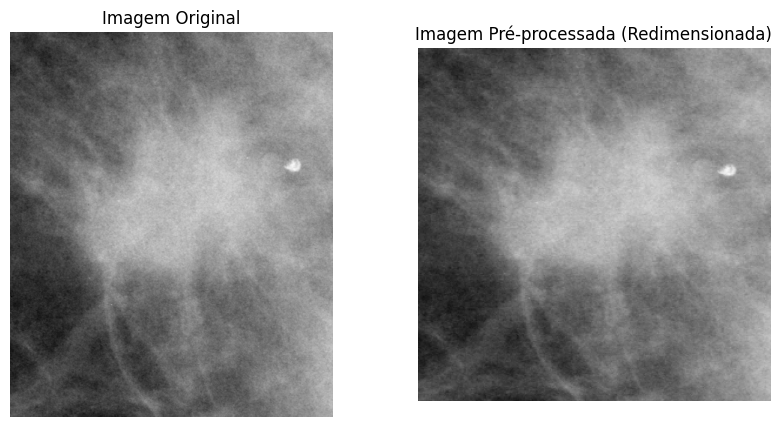

In [ ]:
def preprocess_image(image_path, label, img_size):
    # 1. Lê o arquivo da imagem do disco como uma string de bytes
    image = tf.io.read_file(image_path)

    # 2. Decodifica a string de bytes em um tensor (matriz) com 3 canais de cor (RGB)
    image = tf.image.decode_jpeg(image, channels=3)

    # 3. Redimensiona a imagem para o tamanho padronizado esperado pelo modelo (ex: 224x224)
    image = tf.image.resize(image, img_size)

    # 4. Converte os valores dos pixels de inteiros para números decimais (float32)
    # Nota: Modelos EfficientNet do Keras já fazem a normalização de pixels (0-1) internamente.
    # Por isso, nós NÃO dividimos os pixels por 255.0 aqui.
    image = tf.cast(image, tf.float32)

    return image, label

# --- Criação dos Pipelines de Dados (Data Loaders) ---

# Dataset de Treino: Cria uma lista referenciando os caminhos das imagens e seus rótulos
train_ds = tf.data.Dataset.from_tensor_slices((train_df['img_path'].values, train_df['label'].values))

# Aplica a função de pré-processamento em cada imagem.
# num_parallel_calls=tf.data.AUTOTUNE permite que o TensorFlow decida quantas threads usar para acelerar isso.
train_ds = train_ds.map(lambda x, y: preprocess_image(x, y, IMG_SIZE), num_parallel_calls=tf.data.AUTOTUNE)

# Agrupa os dados em lotes (ex: 32 imagens por vez) e faz o 'prefetch'.
# O prefetch faz com que o CPU já prepare o lote 2 enquanto a GPU ainda está treinando o lote 1.
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de Teste: Repetimos o mesmo processo para as imagens de validação/teste
test_ds = tf.data.Dataset.from_tensor_slices((test_df['img_path'].values, test_df['label'].values))
test_ds = test_ds.map(lambda x, y: preprocess_image(x, y, IMG_SIZE), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Elementos do dataset de treino:", len(train_df))
print("Elementos do dataset de teste:", len(test_df))

# --- Visualização Didática ---
# Vamos pegar a primeira imagem do nosso dataset de treino para ver a diferença
exemplo_path = train_df['img_path'].iloc[0]
exemplo_label = train_df['label'].iloc[0]

# Carrega com OpenCV apenas para exibição original
img_original = cv2.imread(exemplo_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Passa a imagem pela nossa função de pré-processamento
img_precessada, _ = preprocess_image(exemplo_path, exemplo_label, IMG_SIZE)

# Configura o gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_original)
axes[0].set_title("Imagem Original")
axes[0].axis("off")

# Como é um tensor float, convertemos para inteiro (uint8) apenas para o matplotlib conseguir desenhar
axes[1].imshow(img_precessada.numpy().astype("uint8"))
axes[1].set_title("Imagem Pré-processada (Redimensionada)")
axes[1].axis("off")

plt.show()

## Construção e Compilação do Modelo CNN

Nesta etapa, vamos criar a nossa Inteligência Artificial utilizando duas técnicas muito poderosas:

1. **Transfer Learning (Transferência de Aprendizado):** Em vez de treinar uma rede neural do zero, pegamos um modelo muito avançado chamado `EfficientNetB0` que já foi treinado em milhões de imagens genéricas. Ele já sabe identificar bordas, texturas e padrões complexos.
2. **Fine-Tuning (Sintonia Fina):** Como queremos que ele identifique nódulos e calcificações em mamografias (e não cachorros ou carros), nós "descongelamos" a rede para que ela adapte seus conhecimentos prévios a este novo cenário médico.
3. **Data Augmentation (Aumento de Dados):** Aplicamos rotações e espelhamentos aleatórios nas imagens de treino. Isso obriga o modelo a aprender o real formato de um tumor, independentemente se ele estiver virado de ponta cabeça, dificultando que o modelo "decore" os dados (fenômeno chamado de *Overfitting*).

In [ ]:
def build_model(img_size=IMG_SIZE):
    # Define o formato de entrada da rede neural (altura, largura e 3 canais de cor RGB)
    inputs = layers.Input(shape=(img_size[0], img_size[1], 3))

    # --- 1. Data Augmentation (Aumento de Dados) ---
    # O Data Augmentation cria variações artificiais das imagens de treino.
    # Isso evita o "overfitting" (quando o modelo decora as imagens exatas do treino),
    # forçando-o a aprender as características reais de um tumor, independente de sua posição ou iluminação.
    x = tf.keras.Sequential([
        # Espelha a imagem tanto horizontalmente quanto verticalmente.
        # Em recortes de nódulos, a orientação não altera a biologia da anomalia.
        layers.RandomFlip("horizontal_and_vertical"),

        # Gira a imagem em até 20% para simular diferentes ângulos de captura na máquina de raio-x.
        layers.RandomRotation(0.2),

        # Aproxima ou afasta a imagem em até 20%, simulando variações no tamanho da mama ou do equipamento.
        layers.RandomZoom(0.2),

        # Move a imagem para os lados ou para cima/baixo em até 10%. Ajuda o modelo a não presumir
        # que a anomalia estará sempre perfeitamente centralizada na foto.
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

        # Altera o contraste em até 20%. Extremamente crucial para mamografias, pois a densidade
        # do tecido mamário (mamas mais densas ou gordurosas) gera imagens nativamente mais claras ou mais escuras.
        layers.RandomContrast(factor=0.2)
    ], name="data_augmentation")(inputs)

    # --- 2. Modelo Base e Fine-Tuning (Transferência de Aprendizado) ---
    # EfficientNetB3 é uma rede neural profunda que já foi previamente treinada em milhões de imagens (ImageNet).
    # include_top=False: Removemos a última camada (que classificava objetos genéricos como carros ou cães),
    # para que possamos plugar a NOSSA própria camada final especializada em Benigno vs. Maligno.
    # weights="imagenet": Carrega todo esse "conhecimento visual" pré-aprendido para o nosso problema.
    base_model = EfficientNetB3(include_top=False, input_tensor=x, weights="imagenet")

    # Fine-tuning (Sintonia Fina): Ao definir trainable = True, não apenas aproveitamos o conhecimento
    # antigo do modelo, mas permitimos que ele modifique sutilmente seus próprios pesos e neurônios
    # para se adaptar perfeitamente aos contornos e texturas específicas de radiografias mamárias.
    base_model.trainable = True

    # --- 3. Cabeçalho de Classificação (Nossa adaptação) ---
    # GlobalAveragePooling2D: Transforma as matrizes 2D geradas pela EfficientNet em um único vetor 1D numérico.
    x = layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)

    # BatchNormalization: Normaliza os sinais matemáticos, acelerando e estabilizando a velocidade do aprendizado.
    x = layers.BatchNormalization()(x)

    # Dropout atua como um "apagão" temporário e aleatório.
    # Ao desligar 30% (0.3) dos neurônios a cada etapa do treino, obrigamos a rede neural a não
    # depender de uma única característica fácil (um pixel específico) para tomar sua decisão.
    x = layers.Dropout(0.3)(x)

    # Dense: Uma camada de raciocínio intermediário com 128 neurônios artificiais.
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Saída Final: Possui 1 único neurônio com ativação 'sigmoid' (que garante que a saída seja de 0.0 a 1.0).
    # Funciona como uma probabilidade estatística: 0.10 significa "tem cara de benigno", 0.95 "tem cara de maligno".
    outputs = layers.Dense(1, activation="sigmoid", name="predictions")(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model()

# --- 4. Compilação do Modelo ---
model.compile(
    # Adam é o otimizador (o "motor" que ajusta as engrenagens da rede).
    # learning_rate=1e-4 (0.0001): Uma taxa BEM PEQUENA é essencial no Fine-Tuning para
    # ajustar os pesos com suavidade, sem destruir o conhecimento prévio da EfficientNet.
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy', # A equação matemática padrão para medir o erro em problemas de 2 classes
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # AUC mede muito bem a capacidade de diferenciar as classes
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 300, 300,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 300, 300,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 300, 300,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 300, 300,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati

 Total params: 10,986,544 (41.91 MB)

 Trainable params: 10,896,169 (41.57 MB)

 Non-trainable params: 90,375 (353.03 KB)

## Cálculo dos Pesos das Classes

Como o conjunto de dados pode ser desbalanceado (número diferente de casos benignos e malignos), calcularemos os pesos das classes para dar mais importância à classe minoritária durante o treinamento. Isso ajuda a evitar que o modelo fique enviesado para a classe majoritária.

In [ ]:
# --- Cálculo dos Pesos das Classes (Class Weights) ---
# Problema: Na área de saúde, dados de imagens costumam ser desbalanceados.
# Geralmente temos muito mais exames Saudáveis (Benignos) do que Doentes (Malignos).
# Se deixarmos a IA treinar assim, ela pode criar o "vício" de prever tudo como benigno
# só para ganhar uma acurácia artificalmente alta.
#
# Solução: A função 'compute_class_weight' calcula um multiplicador (peso) matemático para cada classe.
# Como a classe 1 (Maligno) possui menos imagens, ela receberá um PESO MAIOR.
# Na prática: Se o modelo prever errado um tumor Maligno, o erro matemático (loss) calculado
# sofrerá uma penalidade muito maior. Isso força o otimizador a prestar o dobro de atenção
# na classe minoritária, balanceando o jogo.

labels = train_df['label'].values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = {i: class_weights[i] for i in range(len(class_weights))}

print("Pesos das classes:", class_weights)


Pesos das classes: {0: np.float64(0.8550595238095238), 1: np.float64(1.2041072925398155)}


## Treinamento do Modelo

Agora treinaremos o modelo CNN usando o `train_ds` e o avaliaremos no `test_ds`. Usaremos os `class_weights` calculados para lidar com qualquer desbalanceamento no conjunto de dados.

Iniciando Treinamento com limite de 30 épocas e monitoramento ativo...
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 94s 344ms/step - accuracy: 0.5614 - auc: 0.5672 - loss: 0.9116 - val_accuracy: 0.6354 - val_auc: 0.6194 - val_loss: 0.6443 - learning_rate: 1.0000e-04
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 295ms/step - accuracy: 0.5701 - auc: 0.5935 - loss: 0.8664 - val_accuracy: 0.5994 - val_auc: 0.6256 - val_loss: 0.6601 - learning_rate: 1.0000e-04
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 294ms/step - accuracy: 0.5976 - auc: 0.6328 - loss: 0.7974 - val_accuracy: 0.5548 - val_auc: 0.6276 - val_loss: 0.6883 - learning_rate: 1.0000e-04
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - accuracy: 0.5966 - auc: 0.6405 - loss: 0.7898 - val_accuracy: 0.5893 - val_auc: 0.6704 - val_loss: 0.6889 - learning_rate: 1.0000e-04
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 294ms/step - accuracy: 0.5976 - auc: 0.6419 - loss: 0.7763 - val_accuracy: 0.6441 - val_auc: 0.6831 - val_loss: 0.6511 - learning_r

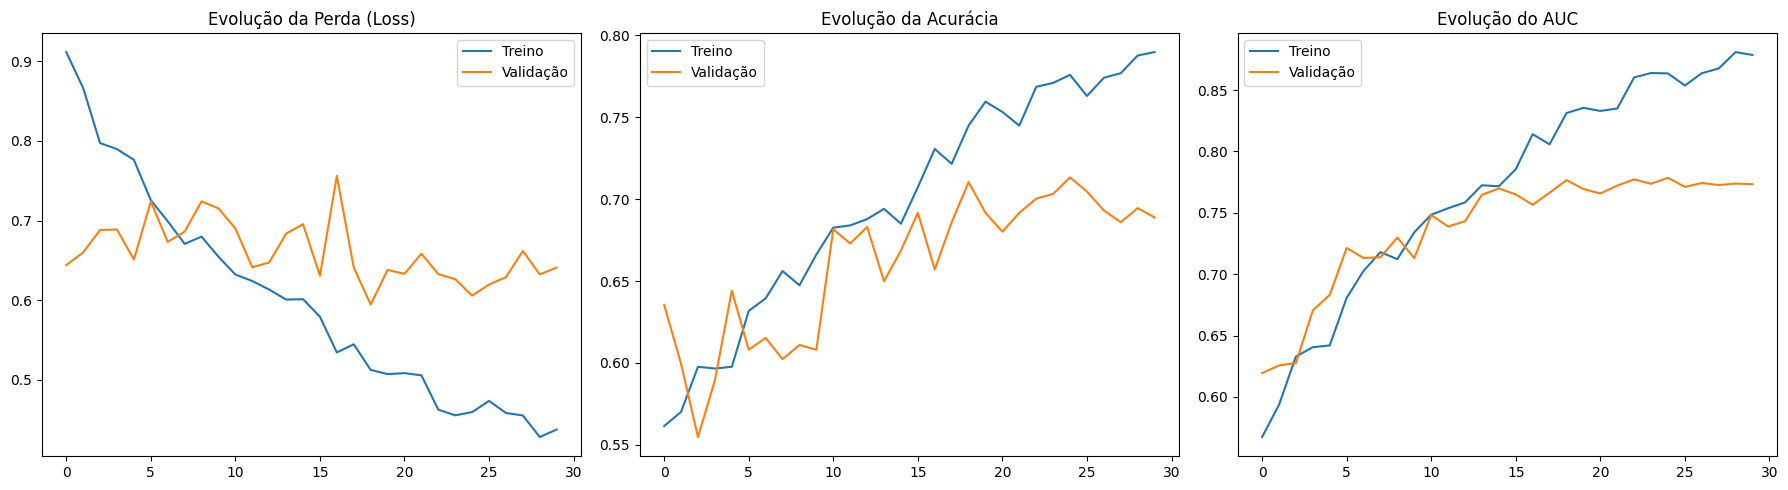

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step


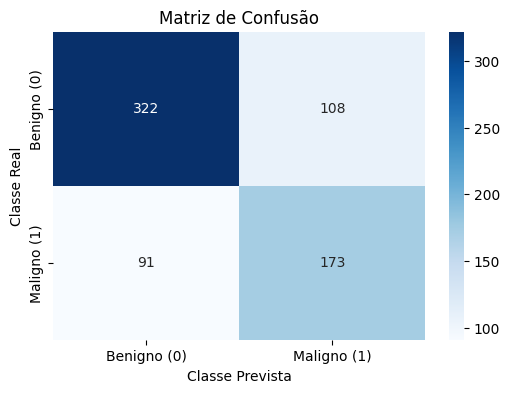

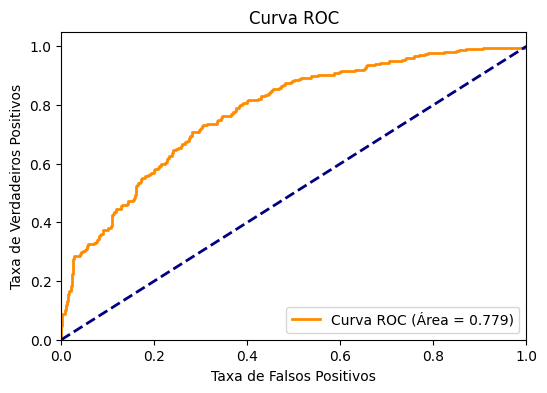

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. Callbacks de Eficiência (Robôs Monitores) ---
# Callbacks são funções automáticas que observam o treinamento ao final de cada época e tomam decisões dinâmicas.

# EarlyStopping (Parada Antecipada):
# Impede o modelo de treinar por tempo demais. Se ele treinar demais, começará a "decorar" os dados
# de treino e perderá a capacidade de generalizar em novos dados.
# - monitor='val_auc': A métrica que ele vai ficar vigiando (AUC de validação).
# - patience=6: O limite de tolerância. Se passar 6 épocas seguidas sem o modelo melhorar o AUC, ele aborta a missão.
# - restore_best_weights=True: Muito importante. Faz o modelo "voltar no tempo" e usar os pesos matemáticos da melhor época que ele alcançou.
early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1)

# ReduceLROnPlateau (Redução de Taxa de Aprendizado em Platô):
# Quando o modelo está chegando perto do resultado ideal, o "passo" que ele dá a cada época pode ser muito
# grande, fazendo ele errar o alvo fino.
# - factor=0.5: Reduz a taxa de aprendizado (learning rate) pela metade (50%).
# - patience=3: Ativa a redução se ele não ver melhora real por 3 épocas.
# Isso funciona como diminuir a velocidade do carro ao estacionar numa vaga apertada.
reduce_lr = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

callbacks_list = [early_stop, reduce_lr]

print("Iniciando Treinamento com limite de 30 épocas e monitoramento ativo...")
history = model.fit(
    train_ds,
    epochs=30,  # Podemos colocar 30 épocas ou mais sem medo, pois o EarlyStopping corta se necessário.
    validation_data=test_ds,
    class_weight=class_weights, # Aplica nossos multiplicadores para a classe minoritária
    callbacks=callbacks_list    # Injeta nossos monitores
)

# Avaliar o modelo no conjunto de teste usando os melhores pesos restaurados
loss, accuracy, auc_score = model.evaluate(test_ds)
print(f"\nPerda no Teste: {loss:.4f}")
print(f"Acurácia no Teste: {accuracy:.4f}")
print(f"AUC no Teste: {auc_score:.4f}")

# --- 2. Geração de Gráficos e Curvas ---
print("\nGerando previsões no conjunto de teste para as curvas avançadas...")

# Gráficos da Evolução do Treinamento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Evolução da Perda (Loss)')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Evolução da Acurácia')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Treino')
axes[2].plot(history.history['val_auc'], label='Validação')
axes[2].set_title('Evolução do AUC')
axes[2].legend()
plt.tight_layout()
plt.show()

# Previsões para Matriz de Confusão e ROC
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds).flatten()
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (0)', 'Maligno (1)'],
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (Área = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()


## Conclusão e Próximos Passos

Ao longo dos nossos testes, o modelo apresentou uma evolução significativa e notável. Inicialmente, enfrentamos desafios com sobreajuste (overfitting) e uma baixa capacidade de generalização, onde o modelo alcançava métricas iniciais fracas (como um AUC próximo a 0.50 e baixa acurácia). Ao refinar nossa abordagem — implementando o aumento da resolução das imagens para 300x300, migrando para uma arquitetura mais profunda (EfficientNetB3), balanceando os pesos das classes (*Class Weights*) e aplicando um *Data Augmentation* mais agressivo e voltado para a variabilidade de imagens radiográficas —, conseguimos dar um salto expressivo, alcançando uma **Acurácia de aproximadamente 71%** e um **AUC de 0.78** no conjunto de teste.

Apesar desse grande avanço, a classificação automática de mamografias é um dos problemas mais complexos da visão computacional médica, pois tumores e anomalias benignas muitas vezes compartilham texturas muito similares. Para **melhorar ainda mais os resultados** no futuro, recomenda-se explorar as seguintes frentes:

1. **Pré-processamento Especializado (Filtros Médicos):** Aplicar técnicas como o **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) antes de passar a imagem para a rede, o que ajuda a destacar o contraste de microcalcificações e contornos de nódulos invisíveis a olho nu.
2. **Abordagem Multimodal:** A medicina não olha apenas para a imagem. Combinar a rede neural de imagens com os dados tabulares estruturados (idade do paciente, densidade da mama, histórico familiar) pode enriquecer drasticamente a capacidade de decisão do modelo.
3. **Segmentação e Detecção (YOLO/U-Net):** Em vez de classificar a imagem inteira, treinar um modelo para desenhar uma "caixa" ou máscara exatamente onde a anomalia está localizada, reduzindo o ruído de fundo (tecido saudável) que confunde a rede.
4. **Ensemble e Novas Arquiteturas:** Combinar as previsões do EfficientNet com outras arquiteturas modernas, como *Vision Transformers (ViT)*, que são excelentes para conectar o contexto de diferentes áreas da imagem.